In [1]:
%cd ..

C:\Users\daanw\PycharmProjects\BSc-Thesis


In [2]:
import os
import torch
from torchvision.transforms import transforms
from torchvision.transforms.v2 import GaussianNoise
from project.models import EDMMauMau
from project.util.device import get_available_acc
from project.util.plotting import plot_sample
from project.util.data import ReplayMemoryData

In [3]:
PATH = os.path.join("checkpoints", "diff", "Fern", "Breakout.pt")
DATA = os.path.join("checkpoints", "memory", "Breakout.pt")
SIGMA = 0.1

In [4]:
device = get_available_acc()
device

'cuda'

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5),
    transforms.Pad(2),
])

In [6]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=100_000
)

In [7]:
model = EDMMauMau.from_checkpoint(PATH, device, sigma_noise=SIGMA).to(device)

In [8]:
x = data[980].to(device)
x += SIGMA * torch.randn_like(x)

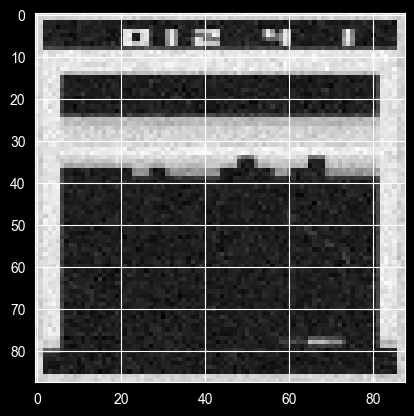

In [9]:
plot_sample(x)

100%|██████████| 8/8 [00:01<00:00,  7.31it/s]


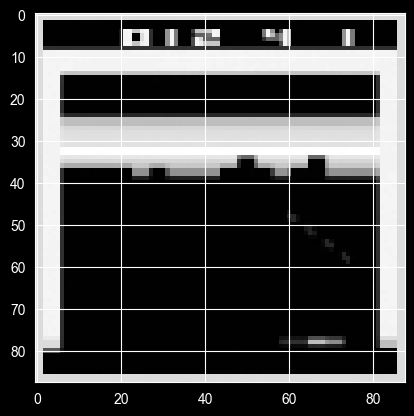

In [10]:
x_denoised = model.denoise(x.unsqueeze(0))
plot_sample(x_denoised.mean(dim=0))

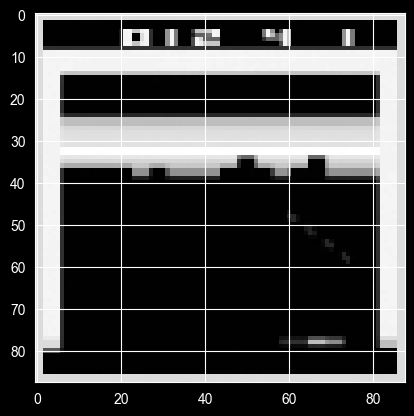

In [11]:
x_naive_denoised = model.naive_denoise(x.unsqueeze(0))
plot_sample(x_denoised.mean(dim=0))